# 🔧 RecycleVision — Data Cleaning & Preprocessing
**Project:** Garbage Image Classification Using Deep Learning  
**Notebook:** 02_Preprocessing.ipynb  
**Goal:** Clean, resize, normalize, augment and split the dataset into Train/Val/Test

## 🔲 Cell 1 — Import Libraries

In [1]:
# Cell 1 - Import Libraries
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image, ImageEnhance, ImageFilter
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 🔲 Cell 2 — Set All Paths

In [2]:
# Cell 2 - Set All Paths
RAW_PATH       = r"D:\RecycleVision\data\raw\Garbage classification"
PROCESSED_PATH = r"D:\RecycleVision\data\processed"
TRAIN_PATH     = os.path.join(PROCESSED_PATH, 'train')
VAL_PATH       = os.path.join(PROCESSED_PATH, 'val')
TEST_PATH      = os.path.join(PROCESSED_PATH, 'test')

# Image settings
IMG_SIZE       = (224, 224)
TRAIN_RATIO    = 0.70
VAL_RATIO      = 0.15
TEST_RATIO     = 0.15
TARGET_COUNT   = 500   # Target images per class after augmentation

# Get class names
classes = sorted(os.listdir(RAW_PATH))
print('📂 Classes:', classes)
print('📐 Image size:', IMG_SIZE)
print('✂️  Split ratio — Train:70%  Val:15%  Test:15%')
print('🎯 Target images per class after augmentation:', TARGET_COUNT)

📂 Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
📐 Image size: (224, 224)
✂️  Split ratio — Train:70%  Val:15%  Test:15%
🎯 Target images per class after augmentation: 500


## 🔲 Cell 3 — Data Cleaning (Remove Corrupt & Non-RGB Images)

In [3]:
# Cell 3 - Data Cleaning
print('=' * 55)
print('🧹 STEP 1: DATA CLEANING')
print('=' * 55)

corrupt_files   = []
non_rgb_fixed   = []
total_valid     = 0

for cls in classes:
    cls_path = os.path.join(RAW_PATH, cls)
    files    = os.listdir(cls_path)
    valid    = 0
    corrupt  = 0
    fixed    = 0

    for fname in files:
        fpath = os.path.join(cls_path, fname)
        try:
            img = Image.open(fpath)
            img.verify()  # Check if image is corrupt

            # Re-open after verify (verify closes the file)
            img = Image.open(fpath)

            # Convert non-RGB to RGB
            if img.mode != 'RGB':
                img = img.convert('RGB')
                img.save(fpath)
                fixed += 1
                non_rgb_fixed.append(fpath)

            valid += 1

        except Exception as e:
            corrupt += 1
            corrupt_files.append(fpath)
            os.remove(fpath)  # Remove corrupt file

    total_valid += valid
    print(f'  {cls:<12} → Valid: {valid}  |  Corrupt removed: {corrupt}  |  Non-RGB fixed: {fixed}')

print('=' * 55)
print(f'✅ Total valid images  : {total_valid}')
print(f'🗑️  Total corrupt removed: {len(corrupt_files)}')
print(f'🔄 Total non-RGB fixed : {len(non_rgb_fixed)}')
print('=' * 55)

🧹 STEP 1: DATA CLEANING
  cardboard    → Valid: 403  |  Corrupt removed: 0  |  Non-RGB fixed: 0
  glass        → Valid: 501  |  Corrupt removed: 0  |  Non-RGB fixed: 0
  metal        → Valid: 410  |  Corrupt removed: 0  |  Non-RGB fixed: 0
  paper        → Valid: 594  |  Corrupt removed: 0  |  Non-RGB fixed: 0
  plastic      → Valid: 482  |  Corrupt removed: 0  |  Non-RGB fixed: 0
  trash        → Valid: 137  |  Corrupt removed: 0  |  Non-RGB fixed: 0
✅ Total valid images  : 2527
🗑️  Total corrupt removed: 0
🔄 Total non-RGB fixed : 0


## 🔲 Cell 4 — Train / Validation / Test Split

In [4]:
# Cell 4 - Train / Val / Test Split
print('=' * 55)
print('✂️  STEP 2: TRAIN / VAL / TEST SPLIT (70/15/15)')
print('=' * 55)

# Create output folder structure
for split in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    for cls in classes:
        os.makedirs(os.path.join(split, cls), exist_ok=True)

split_summary = []

for cls in classes:
    cls_path = os.path.join(RAW_PATH, cls)
    all_images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Shuffle images
    random.shuffle(all_images)

    total     = len(all_images)
    train_end = int(total * TRAIN_RATIO)
    val_end   = int(total * (TRAIN_RATIO + VAL_RATIO))

    train_imgs = all_images[:train_end]
    val_imgs   = all_images[train_end:val_end]
    test_imgs  = all_images[val_end:]

    # Copy images to respective folders
    for fname in train_imgs:
        shutil.copy(os.path.join(cls_path, fname),
                    os.path.join(TRAIN_PATH, cls, fname))

    for fname in val_imgs:
        shutil.copy(os.path.join(cls_path, fname),
                    os.path.join(VAL_PATH, cls, fname))

    for fname in test_imgs:
        shutil.copy(os.path.join(cls_path, fname),
                    os.path.join(TEST_PATH, cls, fname))

    split_summary.append({
        'Class': cls,
        'Total': total,
        'Train': len(train_imgs),
        'Val':   len(val_imgs),
        'Test':  len(test_imgs)
    })

    print(f'  {cls:<12} → Total: {total}  Train: {len(train_imgs)}  Val: {len(val_imgs)}  Test: {len(test_imgs)}')

df_split = pd.DataFrame(split_summary)
print('=' * 55)
print(f'✅ Total Train : {df_split["Train"].sum()}')
print(f'✅ Total Val   : {df_split["Val"].sum()}')
print(f'✅ Total Test  : {df_split["Test"].sum()}')
print('=' * 55)

✂️  STEP 2: TRAIN / VAL / TEST SPLIT (70/15/15)
  cardboard    → Total: 403  Train: 282  Val: 60  Test: 61
  glass        → Total: 501  Train: 350  Val: 75  Test: 76
  metal        → Total: 410  Train: 287  Val: 61  Test: 62
  paper        → Total: 594  Train: 415  Val: 89  Test: 90
  plastic      → Total: 482  Train: 337  Val: 72  Test: 73
  trash        → Total: 137  Train: 95  Val: 21  Test: 21
✅ Total Train : 1766
✅ Total Val   : 378
✅ Total Test  : 383


## 🔲 Cell 5 — Augmentation on Minority Classes (Train Set Only)

In [5]:
# Cell 5 - Data Augmentation on Train Set
print('=' * 55)
print('🔄 STEP 3: DATA AUGMENTATION (Train Set Only)')
print('=' * 55)

def augment_image(img):
    """Apply random augmentations to a PIL image"""
    img = img.copy()

    # Random horizontal flip
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # Random vertical flip
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_TOP_BOTTOM)

    # Random rotation (-20 to +20 degrees)
    angle = random.uniform(-20, 20)
    img = img.rotate(angle, expand=False, fillcolor=(128, 128, 128))

    # Random brightness (0.7 to 1.3)
    factor = random.uniform(0.7, 1.3)
    img = ImageEnhance.Brightness(img).enhance(factor)

    # Random zoom (crop and resize back)
    if random.random() > 0.5:
        w, h   = img.size
        zoom   = random.uniform(0.85, 1.0)
        left   = int(w * (1 - zoom) / 2)
        top    = int(h * (1 - zoom) / 2)
        right  = w - left
        bottom = h - top
        img    = img.crop((left, top, right, bottom))
        img    = img.resize((w, h), Image.LANCZOS)

    # Random contrast (0.8 to 1.2)
    factor = random.uniform(0.8, 1.2)
    img = ImageEnhance.Contrast(img).enhance(factor)

    return img


# Augment minority classes in TRAIN set only
for cls in classes:
    cls_train_path = os.path.join(TRAIN_PATH, cls)
    existing_imgs  = [f for f in os.listdir(cls_train_path)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    current_count  = len(existing_imgs)

    if current_count < TARGET_COUNT:
        needed = TARGET_COUNT - current_count
        print(f'  {cls:<12} → Current: {current_count}  |  Generating: {needed} augmented images...')

        aug_count = 0
        while aug_count < needed:
            # Pick a random source image
            src_fname = random.choice(existing_imgs)
            src_path  = os.path.join(cls_train_path, src_fname)

            try:
                img     = Image.open(src_path).convert('RGB')
                img     = img.resize(IMG_SIZE, Image.LANCZOS)
                aug_img = augment_image(img)

                # Save augmented image
                aug_fname = f'aug_{cls}_{aug_count:04d}.jpg'
                aug_path  = os.path.join(cls_train_path, aug_fname)
                aug_img.save(aug_path, quality=95)
                aug_count += 1

            except Exception as e:
                continue

        new_count = len(os.listdir(cls_train_path))
        print(f'  {cls:<12} → ✅ After augmentation: {new_count} images')

    else:
        print(f'  {cls:<12} → ✅ Already has {current_count} images (no augmentation needed)')

print('=' * 55)
print('✅ Augmentation complete!')
print('=' * 55)

🔄 STEP 3: DATA AUGMENTATION (Train Set Only)
  cardboard    → Current: 282  |  Generating: 218 augmented images...
  cardboard    → ✅ After augmentation: 500 images
  glass        → Current: 350  |  Generating: 150 augmented images...
  glass        → ✅ After augmentation: 500 images
  metal        → Current: 287  |  Generating: 213 augmented images...
  metal        → ✅ After augmentation: 500 images
  paper        → Current: 415  |  Generating: 85 augmented images...
  paper        → ✅ After augmentation: 500 images
  plastic      → Current: 337  |  Generating: 163 augmented images...
  plastic      → ✅ After augmentation: 500 images
  trash        → Current: 95  |  Generating: 405 augmented images...
  trash        → ✅ After augmentation: 500 images
✅ Augmentation complete!


## 🔲 Cell 6 — Resize & Normalize All Images

In [6]:
# Cell 6 - Resize All Images to 224x224
print('=' * 55)
print('📐 STEP 4: RESIZE ALL IMAGES TO 224x224')
print('=' * 55)

def resize_all_images(base_path, splits, classes, img_size):
    for split in splits:
        split_path = os.path.join(base_path, split)
        for cls in classes:
            cls_path = os.path.join(split_path, cls)
            files    = [f for f in os.listdir(cls_path)
                        if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            resized  = 0
            for fname in files:
                fpath = os.path.join(cls_path, fname)
                try:
                    img = Image.open(fpath).convert('RGB')
                    if img.size != img_size:
                        img = img.resize(img_size, Image.LANCZOS)
                        img.save(fpath, quality=95)
                        resized += 1
                except:
                    pass
            print(f'  [{split}] {cls:<12} → {len(files)} images (resized: {resized})')

resize_all_images(PROCESSED_PATH, ['train', 'val', 'test'], classes, IMG_SIZE)

print('=' * 55)
print('✅ All images resized to 224x224!')
print('=' * 55)

📐 STEP 4: RESIZE ALL IMAGES TO 224x224
  [train] cardboard    → 500 images (resized: 282)
  [train] glass        → 500 images (resized: 350)
  [train] metal        → 500 images (resized: 287)
  [train] paper        → 500 images (resized: 415)
  [train] plastic      → 500 images (resized: 337)
  [train] trash        → 500 images (resized: 95)
  [val] cardboard    → 60 images (resized: 60)
  [val] glass        → 75 images (resized: 75)
  [val] metal        → 61 images (resized: 61)
  [val] paper        → 89 images (resized: 89)
  [val] plastic      → 72 images (resized: 72)
  [val] trash        → 21 images (resized: 21)
  [test] cardboard    → 61 images (resized: 61)
  [test] glass        → 76 images (resized: 76)
  [test] metal        → 62 images (resized: 62)
  [test] paper        → 90 images (resized: 90)
  [test] plastic      → 73 images (resized: 73)
  [test] trash        → 21 images (resized: 21)
✅ All images resized to 224x224!


## 🔲 Cell 7 — Verify Final Split Counts

In [7]:
# Cell 7 - Verify Final Counts After Augmentation
print('=' * 65)
print('📊 STEP 5: FINAL SPLIT COUNTS AFTER AUGMENTATION')
print('=' * 65)

summary = []
for cls in classes:
    train_count = len(os.listdir(os.path.join(TRAIN_PATH, cls)))
    val_count   = len(os.listdir(os.path.join(VAL_PATH,   cls)))
    test_count  = len(os.listdir(os.path.join(TEST_PATH,  cls)))
    total       = train_count + val_count + test_count
    summary.append({
        'Class': cls,
        'Train': train_count,
        'Val':   val_count,
        'Test':  test_count,
        'Total': total
    })
    print(f'  {cls:<12} → Train: {train_count:<5} Val: {val_count:<5} Test: {test_count:<5} Total: {total}')

df_final = pd.DataFrame(summary)
print('=' * 65)
print(f'  GRAND TOTAL → Train: {df_final["Train"].sum()}  Val: {df_final["Val"].sum()}  Test: {df_final["Test"].sum()}  Total: {df_final["Total"].sum()}')
print('=' * 65)

📊 STEP 5: FINAL SPLIT COUNTS AFTER AUGMENTATION
  cardboard    → Train: 500   Val: 60    Test: 61    Total: 621
  glass        → Train: 500   Val: 75    Test: 76    Total: 651
  metal        → Train: 500   Val: 61    Test: 62    Total: 623
  paper        → Train: 500   Val: 89    Test: 90    Total: 679
  plastic      → Train: 500   Val: 72    Test: 73    Total: 645
  trash        → Train: 500   Val: 21    Test: 21    Total: 542
  GRAND TOTAL → Train: 3000  Val: 378  Test: 383  Total: 3761


## 🔲 Cell 8 — Visualize Augmented Sample Images

🖼️  Showing sample augmented images from each class...


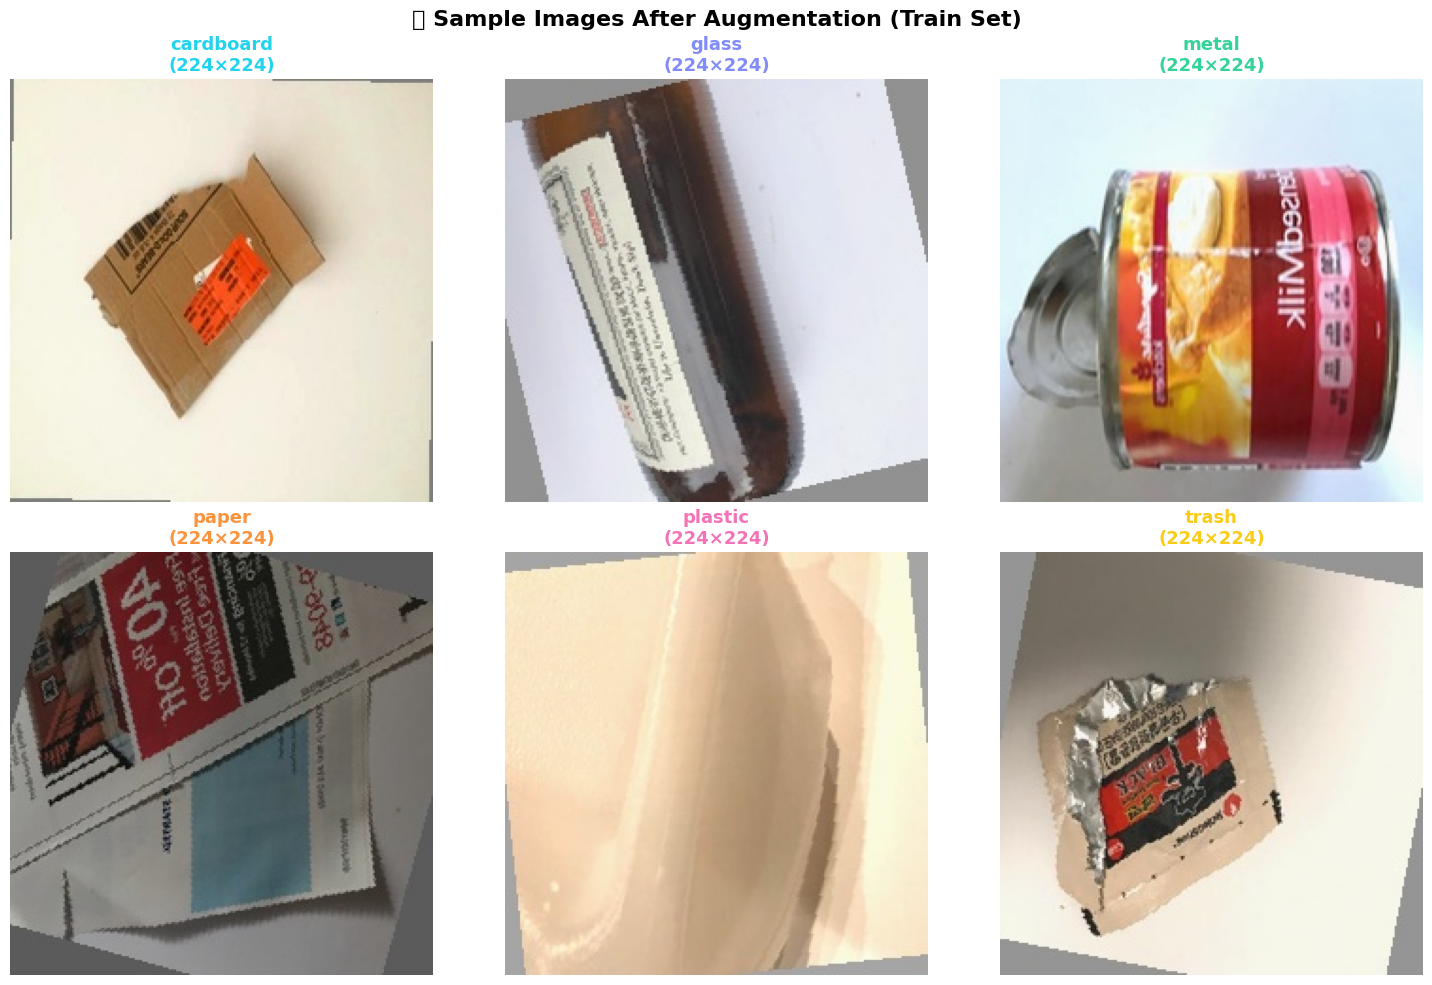

✅ Augmented sample images saved!


In [8]:
# Cell 8 - Visualize Augmented Sample Images
print('🖼️  Showing sample augmented images from each class...')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes      = axes.flatten()
colors    = ['#22d3ee', '#818cf8', '#34d399', '#fb923c', '#f472b6', '#facc15']

for idx, cls in enumerate(classes):
    cls_train_path = os.path.join(TRAIN_PATH, cls)
    aug_images     = [f for f in os.listdir(cls_train_path) if f.startswith('aug_')]

    if aug_images:
        sample_path = os.path.join(cls_train_path, aug_images[0])
    else:
        all_imgs    = os.listdir(cls_train_path)
        sample_path = os.path.join(cls_train_path, all_imgs[0])

    img = Image.open(sample_path).convert('RGB')
    axes[idx].imshow(img)
    axes[idx].set_title(f'{cls}\n(224×224)',
                        fontsize=13, fontweight='bold',
                        color=colors[idx])
    axes[idx].axis('off')
    for spine in axes[idx].spines.values():
        spine.set_edgecolor(colors[idx])
        spine.set_linewidth(3)

plt.suptitle('🔄 Sample Images After Augmentation (Train Set)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(r'D:\RecycleVision\data\augmented_samples.png', dpi=150)
plt.show()
print('✅ Augmented sample images saved!')

## 🔲 Cell 9 — Verify Pixel Values (Normalization Check)

In [9]:
# Cell 9 - Verify Pixel Values & Image Properties
print('=' * 55)
print('🔢 STEP 6: PIXEL VALUE & SIZE VERIFICATION')
print('=' * 55)

# Check a sample image from each class
size_errors  = 0
mode_errors  = 0
total_checked = 0

for cls in classes:
    cls_path = os.path.join(TRAIN_PATH, cls)
    files    = os.listdir(cls_path)[:10]  # Check first 10 images

    for fname in files:
        fpath = os.path.join(cls_path, fname)
        try:
            img   = Image.open(fpath).convert('RGB')
            arr   = np.array(img)
            total_checked += 1

            if img.size != (224, 224):
                size_errors += 1
            if arr.shape[2] != 3:
                mode_errors += 1
        except:
            pass

# Show pixel range (before normalization — normalization happens inside model)
sample_cls  = classes[0]
sample_file = os.listdir(os.path.join(TRAIN_PATH, sample_cls))[0]
sample_path = os.path.join(TRAIN_PATH, sample_cls, sample_file)
sample_img  = np.array(Image.open(sample_path).convert('RGB'))

print(f'  Total images checked : {total_checked}')
print(f'  Size errors (not 224x224) : {size_errors}')
print(f'  Channel errors (not RGB)  : {mode_errors}')
print(f'  Sample image shape : {sample_img.shape}')
print(f'  Pixel range (raw)  : {sample_img.min()} to {sample_img.max()}')
print(f'  Normalized range   : {sample_img.min()/255.0:.3f} to {sample_img.max()/255.0:.3f}')
print('=' * 55)

if size_errors == 0 and mode_errors == 0:
    print('✅ All images are 224x224 RGB — Ready for model training!')
else:
    print(f'⚠️  Found {size_errors} size errors and {mode_errors} mode errors — check above')

print('\n💡 Note: Pixel normalization (÷255) will be applied')
print('         automatically inside the model using')
print('         preprocess_input() from each model.')
print('=' * 55)

🔢 STEP 6: PIXEL VALUE & SIZE VERIFICATION
  Total images checked : 60
  Size errors (not 224x224) : 0
  Channel errors (not RGB)  : 0
  Sample image shape : (224, 224, 3)
  Pixel range (raw)  : 0 to 255
  Normalized range   : 0.000 to 1.000
✅ All images are 224x224 RGB — Ready for model training!

💡 Note: Pixel normalization (÷255) will be applied
         automatically inside the model using
         preprocess_input() from each model.


## 🔲 Cell 10 — Final Preprocessing Summary

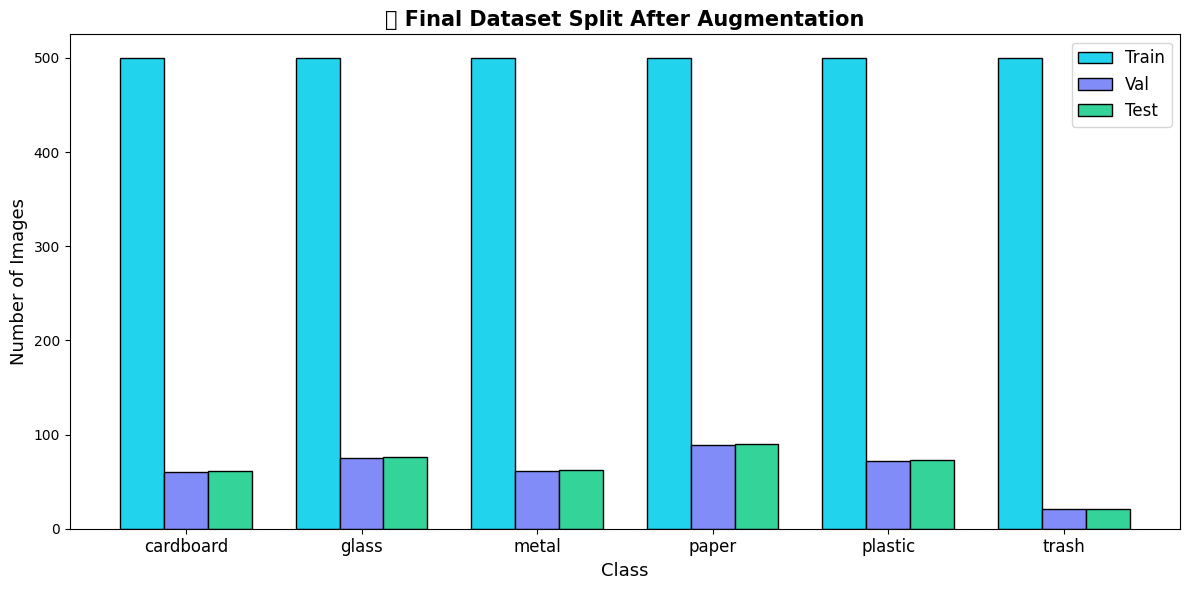

   ✅ PREPROCESSING COMPLETE — SUMMARY
  Image size         : 224 × 224 × 3 (RGB)
  Normalization      : Applied inside model (÷255)
  Train images       : 3000
  Val   images       : 378
  Test  images       : 383
  Total images       : 3761
  Classes            : cardboard, glass, metal, paper, plastic, trash
🔜 Next Step: Model Training (03_Model_Training.ipynb)


In [10]:
# Cell 10 - Final Preprocessing Summary

# Bar chart — final class distribution after augmentation
train_counts = [len(os.listdir(os.path.join(TRAIN_PATH, cls))) for cls in classes]
val_counts   = [len(os.listdir(os.path.join(VAL_PATH,   cls))) for cls in classes]
test_counts  = [len(os.listdir(os.path.join(TEST_PATH,  cls))) for cls in classes]

x      = np.arange(len(classes))
width  = 0.25
colors = ['#22d3ee', '#818cf8', '#34d399']

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, train_counts, width, label='Train', color=colors[0], edgecolor='black')
ax.bar(x,         val_counts,   width, label='Val',   color=colors[1], edgecolor='black')
ax.bar(x + width, test_counts,  width, label='Test',  color=colors[2], edgecolor='black')

ax.set_xlabel('Class', fontsize=13)
ax.set_ylabel('Number of Images', fontsize=13)
ax.set_title('📊 Final Dataset Split After Augmentation', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig(r'D:\RecycleVision\data\final_split.png', dpi=150)
plt.show()

# Print summary
print('=' * 55)
print('   ✅ PREPROCESSING COMPLETE — SUMMARY')
print('=' * 55)
print(f'  Image size         : 224 × 224 × 3 (RGB)')
print(f'  Normalization      : Applied inside model (÷255)')
print(f'  Train images       : {sum(train_counts)}')
print(f'  Val   images       : {sum(val_counts)}')
print(f'  Test  images       : {sum(test_counts)}')
print(f'  Total images       : {sum(train_counts)+sum(val_counts)+sum(test_counts)}')
print(f'  Classes            : {", ".join(classes)}')
print('=' * 55)
print('🔜 Next Step: Model Training (03_Model_Training.ipynb)')
print('=' * 55)